<a href="https://colab.research.google.com/github/OrugboGodswill/British-Airway-Job-Simulation/blob/main/Flight_Booking_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import shap as shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ( classification_report,
                             confusion_matrix,roc_auc_score,
                              precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score )

In [27]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [28]:
# Define the mapping for flight_day
flight_day_mapping = {
    "Sun": 7, "Mon": 1, "Tue": 2, "Wed": 3,
    "Thu": 4, "Fri": 5, "Sat": 6}

df['flight_day'] = df['flight_day'].astype(str).str.strip().str.capitalize().str[:3]

# Apply the mapping to the 'flight_day' column
df['flight_day'] = df['flight_day'].map(flight_day_mapping)

df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0


In [29]:
# Apply LabelEncoder to all remaining object columns after flight_day mapping
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
  df[col] = encoder.fit_transform(df[col])

# Display the DataFrame's info to confirm all object columns are transformed to numerical types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  int64  
 2   trip_type              50000 non-null  int64  
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  int64  
 7   route                  50000 non-null  int64  
 8   booking_origin         50000 non-null  int64  
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 5.3 MB


In [30]:
#Feature Selection.
# Drop rows where 'booking_complete' is NaN, as train_test_split with stratify=y cannot handle NaN in y.
df = df.dropna(subset=['booking_complete'])
X = df.drop(['booking_complete'], axis=1)
y = df['booking_complete']
X

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
0,2,0,2,262,19,7,6,0,61,1,0,0,5.52
1,1,0,2,112,20,3,6,0,61,0,0,0,5.52
2,2,0,2,243,22,17,3,0,36,1,1,0,5.52
3,1,0,2,96,31,4,6,0,61,0,0,1,5.52
4,2,0,2,68,22,15,3,0,36,1,0,1,5.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,0,2,27,6,9,6,720,4,1,0,1,5.62
49996,1,0,2,111,6,4,7,720,4,0,0,0,5.62
49997,1,0,2,24,6,22,6,720,4,0,0,1,5.62
49998,1,0,2,15,6,11,1,720,4,1,0,1,5.62


In [31]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
#initialization Scaler
scaler = StandardScaler()

In [33]:
# Apply StandardScaler to all features in the training data

# All features should be numeric by now, so proceed with scaling
features_to_scale = X_train.columns
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])

X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("X_train after scaling (first 5 rows with scaled features):")
display(X_train.head())

print("\nX_test after scaling (first 5 rows with scaled features):")
display(X_test.head())

X_train after scaling (first 5 rows with scaled features):


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
11179,0.399572,2.818252,0.096156,0.908950,0.443361,-0.197228,-0.908155,-0.314337,-1.046558,-1.425129,-0.651421,1.154574,1.038292
26739,-0.582238,-0.354830,0.096156,-0.345665,-0.588804,-1.487561,1.097349,-1.273244,1.421167,-1.425129,1.535106,-0.866120,-0.437286
16263,-0.582238,-0.354830,0.096156,1.492235,-0.175938,-1.671895,1.598725,0.560994,0.385332,0.701691,-0.651421,1.154574,-1.104968
8082,-0.582238,-0.354830,0.096156,-0.290638,0.384380,-1.487561,-0.406779,-0.617844,-1.046558,-1.425129,-0.651421,1.154574,0.871372
39980,4.326814,-0.354830,0.096156,-0.400692,-0.529823,0.171439,0.595973,0.512609,-0.650503,0.701691,-0.651421,-0.866120,-1.298596



X_test after scaling (first 5 rows with scaled features):


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
15464,-0.582238,-0.35483,0.096156,-0.906939,1.121640,-0.012894,-0.908155,0.345461,0.385332,0.701691,-0.651421,-0.866120,-1.685852
21617,-0.582238,-0.35483,0.096156,-0.147568,-0.116958,-0.197228,0.094597,1.273576,-1.046558,-1.425129,-0.651421,1.154574,1.038292
2108,0.399572,-0.35483,0.096156,1.833402,-0.116958,0.355773,-0.406779,-1.695514,0.385332,0.701691,-0.651421,1.154574,1.038292
588,-0.582238,-0.35483,0.096156,0.842917,-0.028486,0.171439,0.094597,-1.695514,0.689990,0.701691,-0.651421,-0.866120,1.038292
42278,0.399572,-0.35483,0.096156,0.380691,-0.500333,0.171439,-0.406779,-1.695514,0.385332,0.701691,-0.651421,1.154574,1.038292


# **USING OTHER CLASSIFICATION MODELS**

In [ ]:
# @title
# neg, pos = np.bincount(y_train)
# scale_pos_weight = neg / pos

# scale_pos_weight

# rf = RandomForestClassifier( n_estimators=200, max_depth=10,
#     random_state=42, class_weight="balanced")
# xgb = XGBClassifier(
#     objective="binary:logistic", eval_metric="logloss", n_estimators=300,
#     learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
#     scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1
# )

# models = { "rf": rf, "xgb": xgb}

# y_pred = {}

# for name, model in models.items():
#   model.fit(X_train, y_train)
#   y_pred[name] = model.predict(X_test)

# # Initialize K-Fold Cross-Validation
# cv_scores_list = []

# for name, model in models.items():
#   skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
#   cv_results = cross_val_score(model, X_train, y_train, cv=skf )
#   cv_scores_list.append(cv_results)

#   print(f"Cross-Validation Scores for {name}: {cv_results.mean():.4f} +/- {cv_results.std():.4f}")
#   print(f"\n--- Classification Report for {name} (on Test Set) ---")
#   print(classification_report(y_test, y_pred[name]))



np.float64(5.686726847208291)

# **USING RANDOM FOREST CLASSIFICATION MODEL WITH SMOTE & PIPELINE**

In [ ]:
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

pipeline = Pipeline([
  ('smote', SMOTE(random_state=42)),
  ('classifier', RandomForestClassifier( n_estimators=200, max_depth=10,
    random_state=42, class_weight="balanced"))
])


cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf)

print(f"Cross-validation scores: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Fit the pipeline on the entire training data to make predictions on the test set
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))


Cross-validation scores: [0.73046348 0.7240138  0.73226339 0.73286336 0.74317432 0.73267327]
Average CV score: 0.7326 +/- 0.0056

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      8504
           1       0.30      0.62      0.40      1496

    accuracy                           0.72     10000
   macro avg       0.61      0.68      0.61     10000
weighted avg       0.83      0.72      0.76     10000



# **OTHER EVALUATION METRICS**

In [ ]:
roc_auc = roc_auc_score(y_test, y_pred)
roc_auc


np.float64(0.7251381545519944)

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred[name])
pr_auc = auc(recall, precision)

pr_auc

np.float64(0.5426332128317638)

Text(0.5, 0, 'Random Forest Feature Importance')

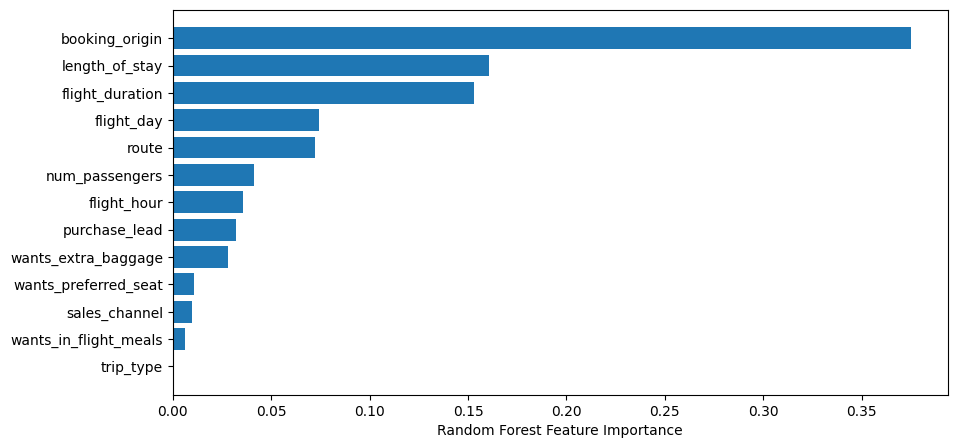

In [ ]:
plt.figure(figsize=(10,5))
sorted_idx = pipeline["classifier"].feature_importances_.argsort()
plt.barh(df.iloc[:,:-1].columns[sorted_idx], pipeline["classifier"].feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")